# Linear Independence, Basis, and Change of Basis

**This notebook is self-contained; it recaps span before building on it.**

Recall that the **span** of some vectors is every point you can reach by scaling and adding them. This notebook makes precise when a vector is **redundant** (its direction was already reachable) versus when it adds something genuinely new. That distinction, **linear dependence vs independence**, leads to the idea of a **basis**: a minimal set of directions that describes a space, and the "coordinate system" we measure vectors against. Redundant directions are also exactly the problem of **collinear predictors** in regression.

## Learning objectives

- Decide whether vectors are **linearly dependent** or **independent**.
- Test dependence by solving a small system of equations (reusing §2.1's elimination).
- Define a **basis** and the **dimension** of a space, and read a vector's **coordinates** in a new basis.

## Background

Vectors are **linearly dependent** if one can be written as a combination of the others (a redundant direction); otherwise they are **linearly independent**. To test whether $\mathbf{u}$ is reachable from $\mathbf{v}$ and $\mathbf{w}$, solve

$$\mathbf{u} = a\mathbf{v} + b\mathbf{w}$$

for the two numbers $a$ and $b$. Reading that one component at a time turns it into an ordinary system of equations in $a$ and $b$, exactly the kind solved in §2.1.

A **basis** is a minimal set of independent vectors that spans the space; the number of them is the **dimension**. An **orthonormal** basis is made of perpendicular unit vectors, the cleanest "axes." Writing a vector **in** a basis means finding the amounts of each basis vector that rebuild it; those amounts are its **coordinates** in that basis. Changing which basis you measure against is a **change of basis**, the same point, described in a different coordinate system.

## This notebook covers

1. Dependent vs independent.
2. Testing dependence by solving a system.
3. Basis and dimension.
4. Change of basis (coordinates in a new system), drawn as two grids over one point.

**Prerequisites:** `U2-2_Vectors-4_LinearCombinationsAndSpan`, `U2-1_Systems-3_GaussianElimination`

**Dataset:** none.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers

# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# plotting helper: draw one vector as an arrow starting at `tail`
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles='xy', scale_units='xy',
              scale=1, color=color, label=label, alpha=alpha, width=0.008)

## 1. Dependent vs independent

Two vectors are **dependent** if one is a scaled copy of the other (same or opposite direction). They are **independent** if they point in genuinely different directions. A quick numeric hint: for two 2D vectors, they are dependent exactly when $v_1 w_2 - v_2 w_1 = 0$ (we will meet this quantity again as the *determinant*).

In [2]:
def dependence_check(v, w):
    return v[0] * w[1] - v[1] * w[0]   # zero means dependent

# each pair written side by side as columns, the way we write them on paper
helpers.show(np.column_stack([[1, 2], [2, 4]]), label="v and w, side by side")
print("  -> check =", dependence_check([1, 2], [2, 4]), ": dependent (= 0)")

helpers.show(np.column_stack([[1, 0], [1, 1]]), label="v and w, side by side")
print("  -> check =", dependence_check([1, 0], [1, 1]), ": independent (not 0)")

<IPython.core.display.Math object>

  -> check = 0 : dependent (= 0)


<IPython.core.display.Math object>

  -> check = 1 : independent (not 0)


## 2. Testing dependence by solving a system

The general test: is $\mathbf{u}$ a combination of $\mathbf{v}$ and $\mathbf{w}$? Try to solve

$$\mathbf{u} = a\mathbf{v} + b\mathbf{w}$$

for $a$ and $b$. Written out one component at a time, with $\mathbf{v} = \begin{bmatrix}1\\0\end{bmatrix}$, $\mathbf{w} = \begin{bmatrix}1\\1\end{bmatrix}$, and $\mathbf{u} = \begin{bmatrix}3\\2\end{bmatrix}$, this is just two equations in two unknowns:

$$\begin{aligned} 1a + 1b &= 3 \quad\text{(first components)}\\ 0a + 1b &= 2 \quad\text{(second components)} \end{aligned}$$

which is exactly the kind of system solved in §2.1. The bottom equation gives $b = 2$ straight away; back-substituting gives $a = 1$. If such $a, b$ exist, $\mathbf{u}$ was already reachable and the three vectors are **dependent**.

In [3]:
v = np.array([1, 0])
w = np.array([1, 1])
u = np.array([3, 2])

# the two equations above, as a coefficient grid and a right-hand side --
# the same augmented-matrix setup used for systems in section 2.1
coeff_grid = np.column_stack([v, w])       # column 1 = v's components, column 2 = w's
helpers.show_aug(coeff_grid, u, label="the system for a and b")

a, b = np.linalg.solve(coeff_grid, u)      # solve it the way section 2.1 did
print(f"a = {a:.0f},  b = {b:.0f}")

# rebuild u as a linear combination -- scaling and adding, nothing more
helpers.show(a * v + b * w, name=r"a\mathbf{v} + b\mathbf{w}")
helpers.show(u, name=r"\mathbf{u}")

<IPython.core.display.Math object>

a = 1,  b = 2


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Since a solution exists, $\mathbf{u}$ lies in the span of $\mathbf{v}$ and $\mathbf{w}$, here $\mathbf{u} = 1\mathbf{v} + 2\mathbf{w}$. (This is also why **collinear predictors** are a problem in regression: if one predictor is a combination of others, the system can't pin down unique coefficients.)

## 3. Basis and dimension

A **basis** is a *minimal* set of independent vectors that spans the space. The standard basis for the plane is

$$\left\{\, \mathbf{e}_1 = \begin{bmatrix}1\\0\end{bmatrix}, \;\; \mathbf{e}_2 = \begin{bmatrix}0\\1\end{bmatrix} \,\right\}$$

, two vectors, so the plane has **dimension** 2. Any independent pair also works as a basis. The cleanest bases are **orthonormal**: perpendicular unit vectors.

In [4]:
e1 = np.array([1, 0])
e2 = np.array([0, 1])
helpers.show(np.column_stack([e1, e2]), label="the standard basis, side by side")

print("orthogonal? e1 . e2 =", np.dot(e1, e2))          # 0 -> perpendicular
print("unit length?", np.linalg.norm(e1), np.linalg.norm(e2))
print("dimension of the plane = number of basis vectors =", 2)

<IPython.core.display.Math object>

orthogonal? e1 . e2 = 0
unit length? 1.0 1.0
dimension of the plane = number of basis vectors = 2


## 4. Change of basis

A vector's coordinates depend on which basis you measure against. The point $(3, 3)$, the vector $\begin{bmatrix}3\\3\end{bmatrix}$ in the standard basis, has *different* coordinates in the basis

$$\left\{\, \mathbf{b}_1 = \begin{bmatrix}2\\1\end{bmatrix}, \;\; \mathbf{b}_2 = \begin{bmatrix}-1\\1\end{bmatrix} \,\right\}.$$

To find them, ask the same question as before: how much of each basis vector rebuilds the point?

$$c_1\mathbf{b}_1 + c_2\mathbf{b}_2 = \begin{bmatrix}3\\3\end{bmatrix}$$

Component by component that is again two equations in two unknowns:

$$\begin{aligned} 2c_1 - 1c_2 &= 3\\ 1c_1 + 1c_2 &= 3 \end{aligned}$$

Solving gives $c_1 = 2$, $c_2 = 1$. Those two numbers are the point's **coordinates in the new basis**, and note that "standard coordinates" were never special: $\begin{bmatrix}3\\3\end{bmatrix}$ just means $3\mathbf{e}_1 + 3\mathbf{e}_2$, the same kind of recipe written against the usual axes.

In [5]:
b1 = np.array([2, 1])       # the new basis vectors
b2 = np.array([-1, 1])
point = np.array([3, 3])

helpers.show(point, label="standard coordinates")

# solve  c1*b1 + c2*b2 = point  for c1, c2 -- again just a 2-equation system
coeff_grid = np.column_stack([b1, b2])
helpers.show_aug(coeff_grid, point, label="the system for c1 and c2")

c1, c2 = np.linalg.solve(coeff_grid, point)
print(f"c1 = {c1:.0f},  c2 = {c2:.0f}")

# rebuild the point from the new basis: scale each basis vector and add
helpers.show(np.round(c1 * b1 + c2 * b2, 3), label="c1 b1 + c2 b2, rebuilt")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

c1 = 2,  c2 = 1


<IPython.core.display.Math object>

The two descriptions are worth *seeing*, because "the same point, different coordinates" is hard to
believe from numbers alone.

Both panels below show the **same dot in the same place**. What changes is the grid we measure it
against, and therefore the pair of numbers we read off.

- **Left:** the standard grid, ruled by $\mathbf{e}_1$ and $\mathbf{e}_2$. Walk 3 across and 3 up.
- **Right:** the grid ruled by $\mathbf{b}_1$ and $\mathbf{b}_2$, which is tilted. Walk 2 steps along
  $\mathbf{b}_1$ and 1 step along $\mathbf{b}_2$ and you land on exactly the same dot.

The dashed arrows trace each walk. Neither grid is more correct than the other; the standard one is
just the one we are used to.


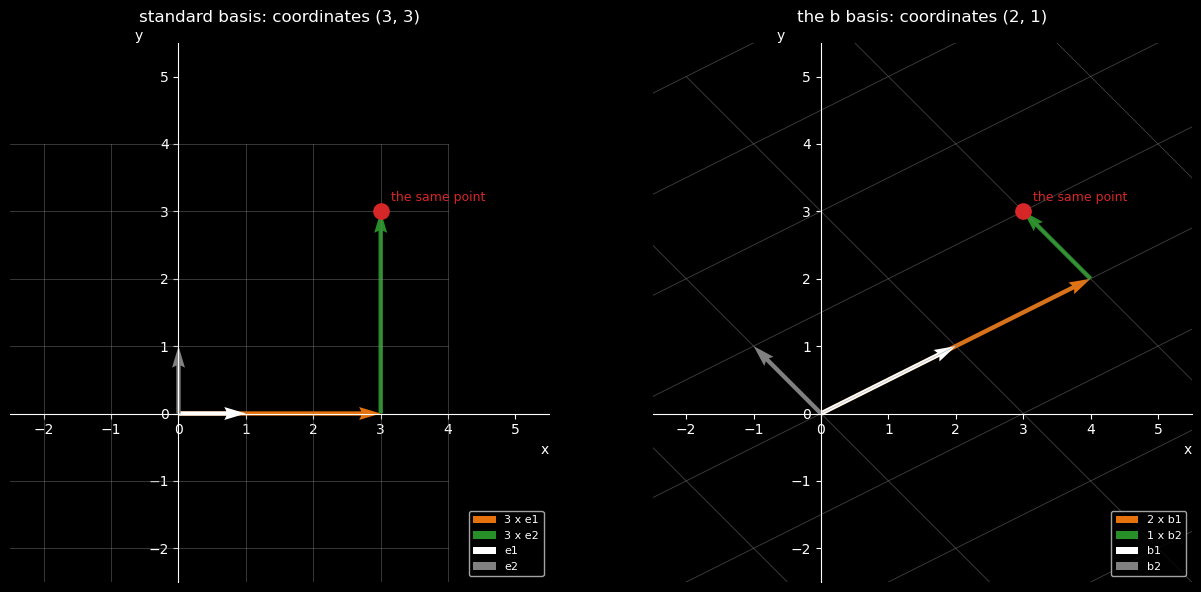

In [6]:
# --- graphics: the same point read against two different grids ---
def draw_grid(ax, u, v, n=4, color="gray"):
    """Rule the plane with lines parallel to u and to v (the grid that basis makes)."""
    for k in range(-n, n + 1):
        # lines in the direction of u, offset along v (and vice versa)
        p0, p1 = k * v - n * u, k * v + n * u
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, lw=0.6, alpha=0.5)
        p0, p1 = k * u - n * v, k * u + n * v
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, lw=0.6, alpha=0.5)

e1 = np.array([1, 0])
e2 = np.array([0, 1])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

panels = [
    (axes[0], e1, e2, point[0], point[1], "e", "standard basis"),
    (axes[1], b1, b2, c1,       c2,       "b", "the b basis"),
]

for ax, u, v, a, b, letter, title in panels:
    draw_grid(ax, u, v)
    # the walk: a steps along u, then b steps along v
    arrow(ax, (0, 0), a * u, "tab:orange", f"{a:.0f} x {letter}1", alpha=0.9)
    arrow(ax, a * u, b * v, "tab:green", f"{b:.0f} x {letter}2", alpha=0.9)
    # the basis vectors themselves, at unit scale
    arrow(ax, (0, 0), u, "white", f"{letter}1")
    arrow(ax, (0, 0), v, "gray", f"{letter}2")

    ax.plot(point[0], point[1], "o", color="tab:red", markersize=11, zorder=6)
    ax.text(point[0] + 0.15, point[1] + 0.15, "the same point", color="tab:red", fontsize=9)

    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.set_ylabel("y", loc="top", rotation=0)
    ax.set_xlim(-2.5, 5.5); ax.set_ylim(-2.5, 5.5); ax.set_aspect("equal")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_title(f"{title}: coordinates ({a:.0f}, {b:.0f})", pad=15)

plt.tight_layout()
plt.show()


The same point is $\begin{bmatrix}3\\3\end{bmatrix}$ in standard coordinates but $\begin{bmatrix}2\\1\end{bmatrix}$ in the new basis, one location, two descriptions. (This idea, that a change of basis re-expresses the same object in a new coordinate system, is exactly what MSCS 540 later calls "a basis is a language.")

## 5. Summary

- Vectors are **dependent** if one is a combination of the others, **independent** otherwise.
- Test dependence by solving $\mathbf{u} = a\mathbf{v} + b\mathbf{w}$, component by component, an ordinary system of equations.
- A **basis** is a minimal independent spanning set; its size is the **dimension**; **orthonormal** bases are perpendicular unit vectors.
- **Change of basis** re-expresses the same point in different coordinates: solve $c_1\mathbf{b}_1 + c_2\mathbf{b}_2 = \mathbf{p}$ for the amounts $c_1, c_2$.

Next: matrices, grids of numbers, their arithmetic, and the special ones worth naming (`U2-3_Matrices-1_ArithmeticAndSpecial`). Once matrix multiplication is in hand, the systems in this notebook get a much shorter notation.